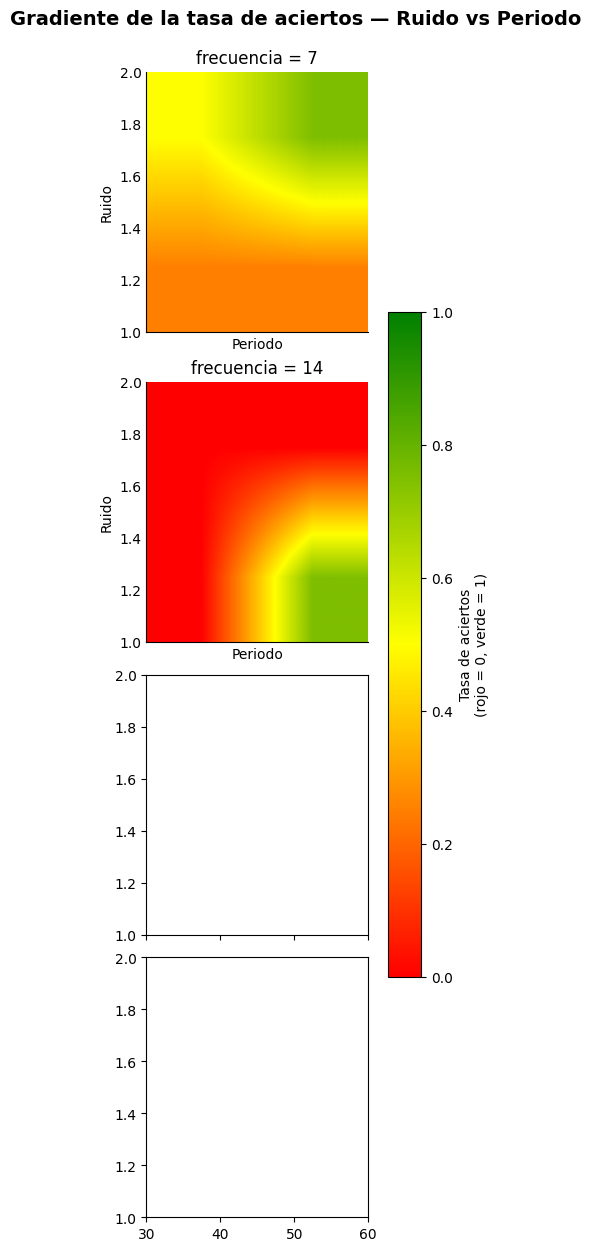

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ── 1. Cargar datos ──────────────────────────────────────────────
df = pd.read_csv("data/sensibilidad.csv")          # ajusta la ruta si es necesario

# ── 2. Tasa de aciertos por (frecuencia, ruido, periodo) ─────────
agg = (df.groupby(["frec_obs", "ruido", "periodo"], as_index=False)["ok"]
         .mean()
         .rename(columns={"ok": "tasa"}))           # 0-1 continuo

# ── 3. Seleccionar las primeras 4 frecuencias ────────────────────
freqs = sorted(agg["frec_obs"].unique())[:4]

# ── 4. Colormap “éxito-fracaso” verde→amarillo→rojo ──────────────
cmap = LinearSegmentedColormap.from_list(
    "success_fail", ["red", "yellow", "green"], N=256
)                                   # 0 = rojo (fracaso), 1 = verde (éxito)

# ── 5. Configurar la figura ──────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(4, 12),
                         sharex=True, sharey=True,
                         constrained_layout=True)

for ax, f in zip(axes.flat, freqs):
    sub = agg[agg["frec_obs"] == f]

    # Matriz (ruido × periodo) ordenada
    grid = (sub.pivot_table(index="ruido", columns="periodo", values="tasa")
               .sort_index()
               .sort_index(axis=1))

    # Interpolar NaN para obtener un degradado liso
    arr = (grid
           .ffill(axis=0).bfill(axis=0)     # columnas
           .ffill(axis=1).bfill(axis=1)     # filas
           .values)

    # Mostrar el degradado continuo (sin escala log, sin números)
    im = ax.imshow(arr,
                   origin="lower",
                   aspect="auto",
                   cmap=cmap,
                   vmin=0, vmax=1,
                   interpolation="bilinear",
                   extent=[grid.columns.min(), grid.columns.max(),
                           grid.index.min(),   grid.index.max()])

    # Etiquetas mínimas
    ax.set_title(f"frecuencia = {f}", pad=6)
    ax.set_xlabel("Periodo")
    ax.set_ylabel("Ruido")

    # Ticks externos muy discretos
    ax.tick_params(which="both", length=0)
    ax.spines[["top", "right"]].set_visible(False)

# ── 6. Barra de color única ──────────────────────────────────────
cbar = fig.colorbar(im, ax=axes.ravel().tolist(),
                    shrink=0.85, label="Tasa de aciertos\n(rojo = 0, verde = 1)")

fig.suptitle("Gradiente de la tasa de aciertos — Ruido vs Periodo",
             y=1.03, fontsize=14, weight="bold")
plt.savefig('sensibilidad.png')
plt.show()
